# CNN + Selective Search

## 載入套件

In [ ]:
from typing import List, Tuple, Union, cast

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch.nn import functional as F
from torchvision import models, transforms


In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [3]:
device = "cpu"

In [4]:
# 參數設定
WIDTH = 600  # 圖像縮放為 (600, 600)
INPUT_SIZE = (224, 224)  # CNN的輸入尺寸

## 載入 ResNet50 模型

In [5]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device)

## 讀取要辨識的圖片

In [6]:
filename = 'images_Object_Detection/bike.jpg'
orig = Image.open(filename)
# 等比例縮放圖片
orig = orig.resize((WIDTH, int(orig.size[1] / orig.size[0] * WIDTH)))
Width_Height_ratio = orig.size[1] / orig.size[0]
orig.size

(600, 400)

## 定義轉換函數

In [7]:
# 轉換函數
transform = transforms.Compose(
    [
        transforms.Resize(INPUT_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


# PIL格式轉換為OpenCV格式
def PIL2CV2(orig: Image.Image) -> np.ndarray:
    pil_image = orig.copy()
    open_cv_image = np.array(pil_image)
    return open_cv_image[:, :, ::-1].copy()

## 以Selective Search取代滑動視窗及影像金字塔，取得每一個要偵測的視窗

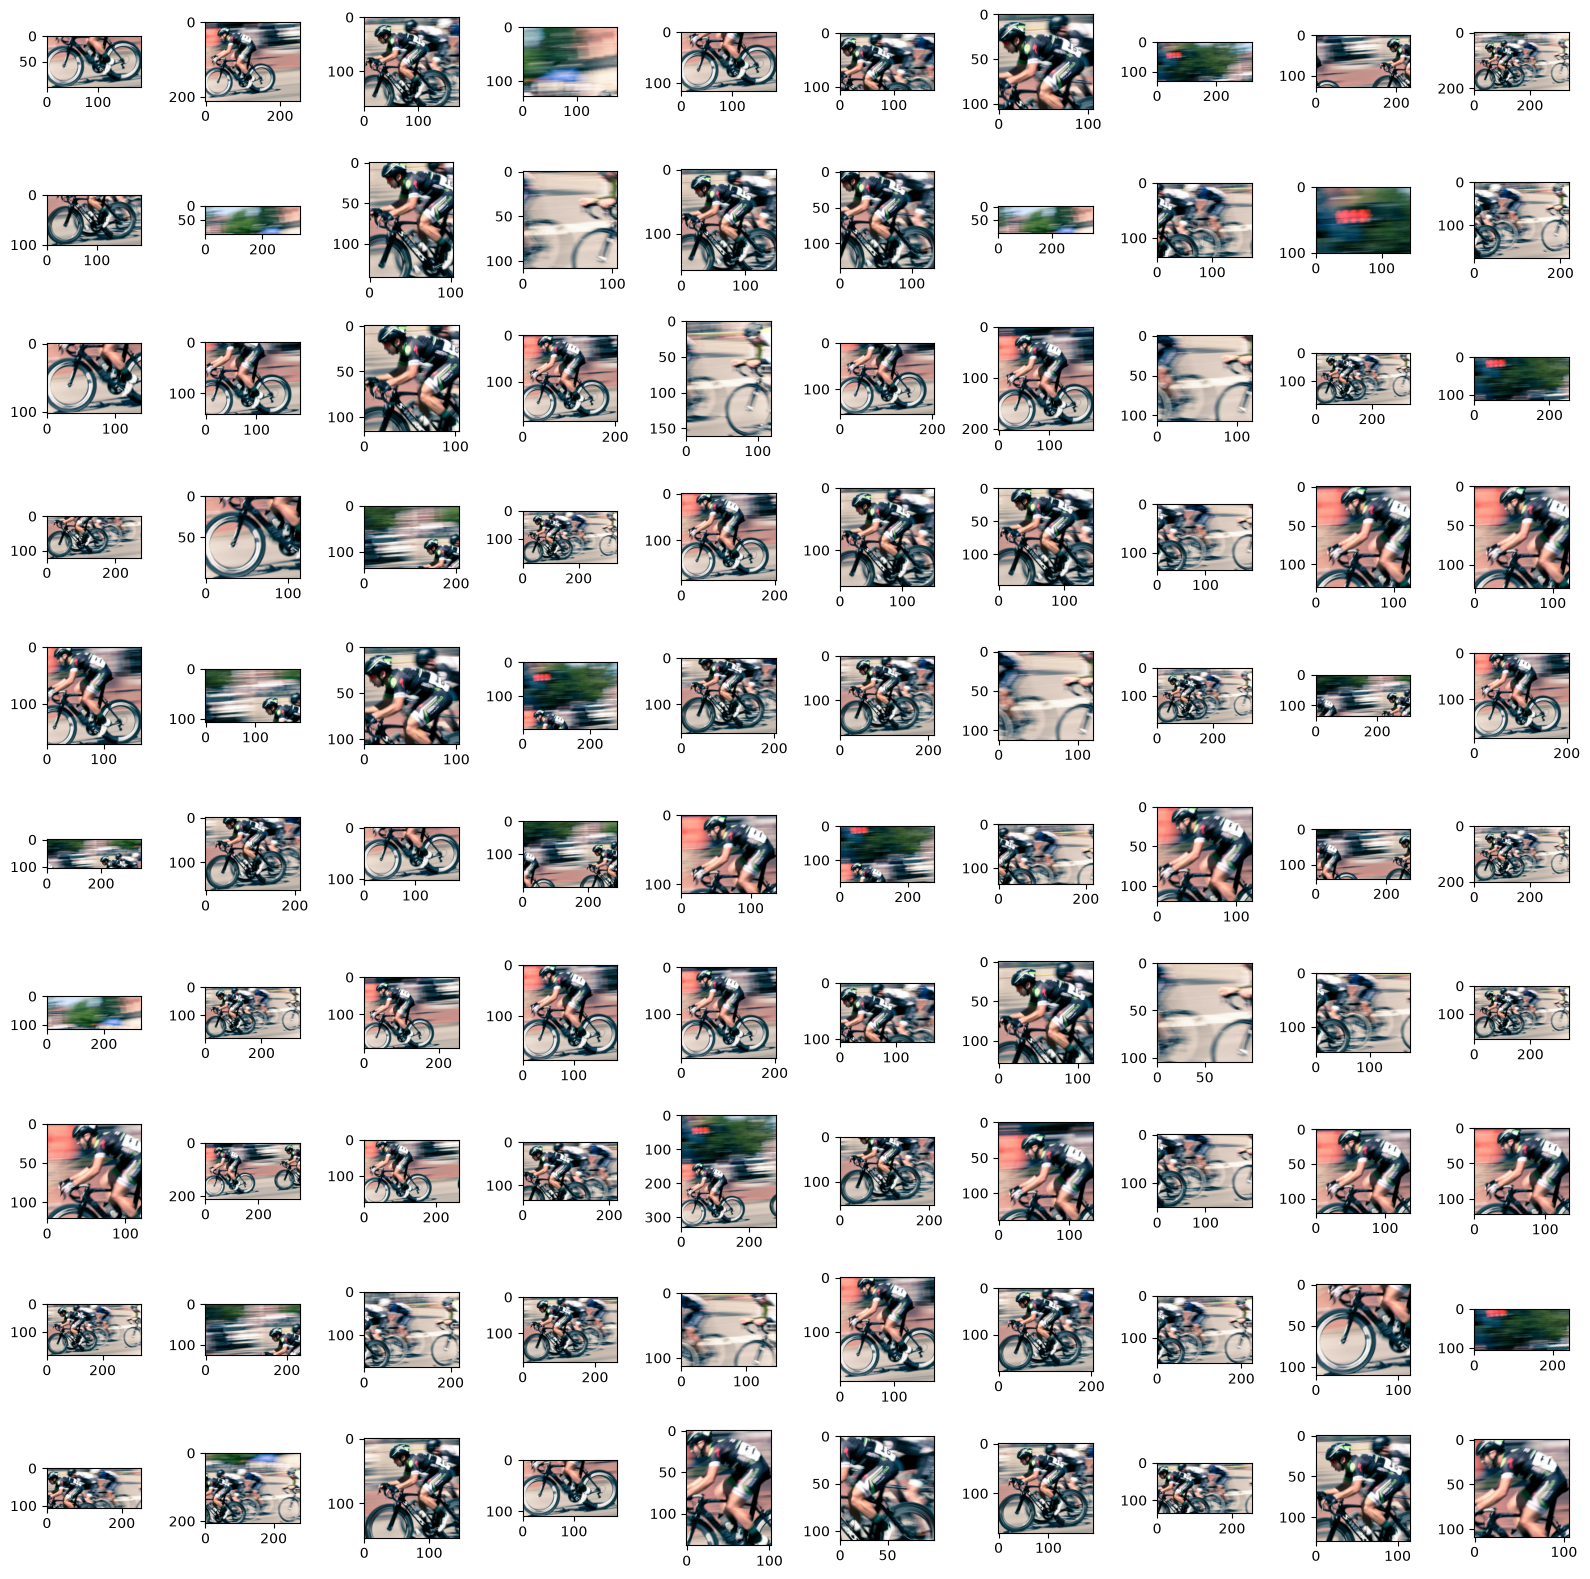

In [ ]:
# 產生 Selective Search 影像
plt.figure(figsize=(16, 16))


def selective_search(img_path: str) -> Tuple[torch.Tensor, List[Tuple[int, int, int, int]]]:
    img = cv2.imread(img_path)
    img = cv2.resize(img, (WIDTH, int(orig.size[1] / orig.size[0] * WIDTH)), interpolation=cv2.INTER_AREA)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 執行 Selective Search
    cv2.setUseOptimized(True)
    cv2.setNumThreads(8)
    gs = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    gs.setBaseImage(img)
    gs.switchToSelectiveSearchFast()
    rects = gs.process()
    # print(rects)

    rois = torch.tensor([])  # 候選框
    locs: list[tuple] = []  # 位置
    j = 1
    for i in range(len(rects)):
        x, y, w, h = rects[i]
        if w < 100 or w > 400 or h < 100:
            continue

        # 框與原圖的比例
        scale = WIDTH / float(w)

        # 縮放圖形以符合模型輸入規格
        crop_img = img[y : y + h, x : x + w]
        crop_img = Image.fromarray(crop_img)
        if j <= 100:
            plt.subplot(10, 10, j)
            plt.imshow(crop_img)
        j += 1

        roi = cast(torch.Tensor, transform(crop_img))
        roi = roi.unsqueeze(0)  # 增加一維(筆數)

        # 加入輸出變數中
        if len(rois.shape) == 1:
            rois = roi
        else:
            rois = torch.cat((rois, roi), dim=0)
        locs.append((x, y, x + w, y + h))

    return rois.to(device), locs


rois, locs = selective_search(filename)
plt.tight_layout()

In [9]:
rois.shape

torch.Size([242, 3, 224, 224])

In [10]:
len(locs)

242

In [11]:
locs

[(np.int32(0), np.int32(228), np.int32(186), np.int32(328)),
 (np.int32(0), np.int32(126), np.int32(254), np.int32(337)),
 (np.int32(280), np.int32(119), np.int32(455), np.int32(283)),
 (np.int32(424), np.int32(0), np.int32(600), np.int32(128)),
 (np.int32(0), np.int32(212), np.int32(186), np.int32(328)),
 (np.int32(300), np.int32(125), np.int32(476), np.int32(231)),
 (np.int32(300), np.int32(125), np.int32(406), np.int32(231)),
 (np.int32(0), np.int32(0), np.int32(320), np.int32(131)),
 (np.int32(122), np.int32(126), np.int32(357), np.int32(256)),
 (np.int32(260), np.int32(96), np.int32(600), np.int32(303)),
 (np.int32(262), np.int32(203), np.int32(452), np.int32(304)),
 (np.int32(268), np.int32(0), np.int32(600), np.int32(100)),
 (np.int32(284), np.int32(137), np.int32(388), np.int32(279)),
 (np.int32(481), np.int32(141), np.int32(587), np.int32(250)),
 (np.int32(284), np.int32(125), np.int32(432), np.int32(283)),
 (np.int32(302), np.int32(141), np.int32(434), np.int32(276)),
 (np.in

## 預測

In [12]:
# 讀取類別列表
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

# 預測
model.eval()
with torch.no_grad():
    output = model(rois)

# 轉成機率
probabilities = F.softmax(output, dim=1)

# 取得第一名
top_prob, top_catid = torch.topk(probabilities, 1)
probabilities

tensor([[0.0005, 0.0007, 0.0003,  ..., 0.0004, 0.0006, 0.0003],
        [0.0005, 0.0009, 0.0004,  ..., 0.0005, 0.0005, 0.0008],
        [0.0004, 0.0005, 0.0003,  ..., 0.0004, 0.0004, 0.0007],
        ...,
        [0.0003, 0.0005, 0.0002,  ..., 0.0004, 0.0003, 0.0008],
        [0.0004, 0.0007, 0.0003,  ..., 0.0004, 0.0003, 0.0007],
        [0.0004, 0.0006, 0.0003,  ..., 0.0004, 0.0005, 0.0007]])

In [13]:
top_catid.numpy().reshape(-1)

array([823, 671, 671, 670, 671, 671, 444, 665, 671, 671, 671, 670, 671,
       444, 671, 671, 670, 665, 518, 444, 444, 671, 444, 671, 518, 671,
       671, 612, 671, 670, 671, 671, 518, 671, 671, 671, 671, 870, 671,
       444, 671, 518, 444, 518, 671, 671, 444, 671, 671, 671, 612, 671,
       444, 671, 671, 518, 671, 444, 444, 671, 468, 671, 671, 671, 671,
       671, 444, 665, 612, 671, 444, 518, 518, 671, 671, 671, 444, 671,
       671, 671, 671, 518, 671, 671, 444, 671, 671, 671, 444, 612, 444,
       671, 671, 671, 671, 444, 671, 671, 444, 444, 671, 444, 444, 671,
       518, 671, 671, 671, 612, 518, 671, 670, 444, 665, 671, 444, 670,
       444, 671, 444, 671, 691, 518, 518, 670, 468, 444, 518, 518, 671,
       444, 671, 671, 518, 671, 518, 671, 823, 444, 518, 671, 612, 444,
       671, 671, 612, 671, 612, 671, 870, 518, 444, 518, 444, 671, 671,
       671, 518, 670, 671, 670, 671, 671, 444, 612, 671, 671, 444, 671,
       671, 671, 444, 671, 671, 671, 671, 444, 671, 671, 444, 67

In [14]:
for i in range(probabilities.shape[0]):
    print(i, probabilities[i, 671].item())

0 0.05588049069046974
1 0.18680478632450104
2 0.4038321077823639
3 0.024788714945316315
4 0.2514745891094208
5 0.07964570075273514
6 0.0789840891957283
7 0.02728719636797905
8 0.30255237221717834
9 0.32664331793785095
10 0.16429893672466278
11 0.020144401118159294
12 0.15720322728157043
13 0.11550880968570709
14 0.4630405306816101
15 0.40311887860298157
16 0.024149905890226364
17 0.12228449434041977
18 0.02379004843533039
19 0.0674915611743927
20 0.09882565587759018
21 0.2800522744655609
22 0.08324811607599258
23 0.35142701864242554
24 0.12554478645324707
25 0.28846070170402527
26 0.27606135606765747
27 0.03632254898548126
28 0.19780656695365906
29 0.02981303259730339
30 0.12264657765626907
31 0.15519951283931732
32 0.05527109652757645
33 0.2458779513835907
34 0.29052555561065674
35 0.358477920293808
36 0.40594661235809326
37 0.05559239536523819
38 0.1853194236755371
39 0.2009955495595932
40 0.329664945602417
41 0.039353735744953156
42 0.10599690675735474
43 0.22694280743598938
44 0.52

In [15]:
probabilities[0, 671]

tensor(0.0559)

## 檢查預測結果，辨識機率須大於設定值

In [16]:
MIN_CONFIDENCE = 0.4  # 辨識機率門檻值

labels: dict[str, list] = {}
for i, p in enumerate(zip(top_prob.numpy().reshape(-1), top_catid.numpy().reshape(-1))):
    prob, imagenetID = p
    label = categories[imagenetID]

    # 機率大於設定值，則放入候選名單
    if prob >= MIN_CONFIDENCE:
        # 只偵測自行車(671)
        if imagenetID != 671:
            continue  # bike
        # 放入候選名單
        box = locs[i]
        print(i, imagenetID)
        L = labels.get(label, [])
        L.append((box, prob))
        labels[label] = L

labels.keys()

2 671
14 671
15 671
36 671
44 671
45 671
51 671
53 671
75 671
83 671
110 671
114 671
148 671
175 671
180 671
190 671
194 671
208 671
215 671
226 671
237 671


dict_keys(['mountain bike'])

In [17]:
labels['mountain bike']

[((np.int32(280), np.int32(119), np.int32(455), np.int32(283)),
  np.float32(0.4038321)),
 ((np.int32(284), np.int32(125), np.int32(432), np.int32(283)),
  np.float32(0.46304053)),
 ((np.int32(302), np.int32(141), np.int32(434), np.int32(276)),
  np.float32(0.40311888)),
 ((np.int32(280), np.int32(135), np.int32(424), np.int32(283)),
  np.float32(0.4059466)),
 ((np.int32(262), np.int32(141), np.int32(466), np.int32(303)),
  np.float32(0.5215728)),
 ((np.int32(262), np.int32(125), np.int32(476), np.int32(304)),
  np.float32(0.41416904)),
 ((np.int32(260), np.int32(142), np.int32(472), np.int32(305)),
  np.float32(0.5441084)),
 ((np.int32(86), np.int32(62), np.int32(375), np.int32(262)),
  np.float32(0.42501006)),
 ((np.int32(260), np.int32(152), np.int32(472), np.int32(305)),
  np.float32(0.48670343)),
 ((np.int32(260), np.int32(125), np.int32(522), np.int32(305)),
  np.float32(0.41400316)),
 ((np.int32(262), np.int32(75), np.int32(600), np.int32(307)),
  np.float32(0.44857112)),
 ((np.

## 定義NMS函數

In [18]:
def non_max_suppression_slow(boxes: np.ndarray, overlapThresh: float = 0.5) -> Union[np.ndarray, list]:
    if len(boxes) == 0:
        return []

    pick = []  # 儲存篩選的結果
    x1 = boxes[:, 0]  # 取得候選的視窗的左/上/右/下 座標
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    # 計算候選視窗的面積
    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(y2)  # 依視窗的底Y座標排序

    # 比對重疊比例
    while len(idxs) > 0:
        # 最後一筆
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)
        suppress = [last]

        # 比對最後一筆與其他視窗重疊的比例
        for pos in range(0, last):
            j = idxs[pos]

            # 取得所有視窗的涵蓋範圍
            xx1 = max(x1[i], x1[j])
            yy1 = max(y1[i], y1[j])
            xx2 = min(x2[i], x2[j])
            yy2 = min(y2[i], y2[j])
            w = max(0, xx2 - xx1 + 1)
            h = max(0, yy2 - yy1 + 1)

            # 計算重疊比例
            overlap = float(w * h) / area[j]

            # 如果大於門檻值，則儲存起來
            if overlap > overlapThresh:
                suppress.append(pos)

        # 刪除合格的視窗，繼續比對
        idxs = np.delete(idxs, suppress)

    # 傳回合格的視窗
    return boxes[pick]

## 進行 NMS，並對偵測到的物件畫框

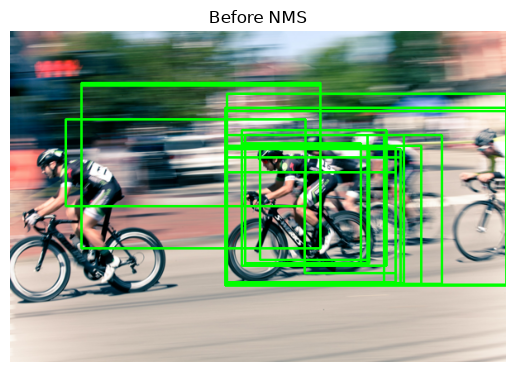

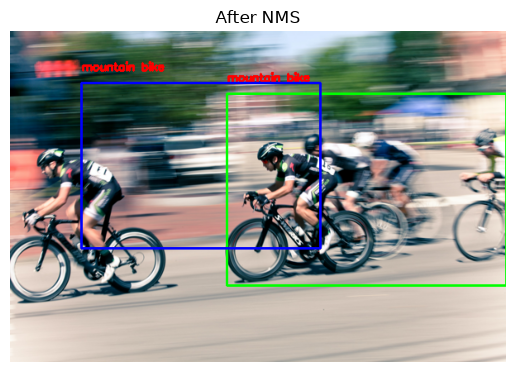

In [19]:
# 掃描每一個類別
for label in labels.keys():
    # if label != categories[671]: continue # bike

    # 複製原圖
    open_cv_image = PIL2CV2(orig)

    # 畫框
    for box, prob in labels[label]:
        startX, startY, endX, endY = box
        cv2.rectangle(open_cv_image, (startX, startY), (endX, endY), (0, 255, 0), 2)

    # 顯示 NMS(non-maxima suppression) 前的框
    plt.imshow(cv2.cvtColor(open_cv_image, cv2.COLOR_BGR2RGB))
    plt.title("Before NMS")
    plt.axis("off")
    plt.show()

    # NMS
    open_cv_image2 = PIL2CV2(orig)
    boxes = np.array([p[0] for p in labels[label]])
    proba = np.array([p[1] for p in labels[label]])
    boxes = non_max_suppression_slow(boxes, MIN_CONFIDENCE)  # non max suppression

    color_list = [(0, 255, 0), (255, 0, 0), (255, 255, 0), (0, 0, 0), (0, 255, 255)]
    for i, x in enumerate(boxes):
        # startX, startY, endX, endY, label = x.numpy()
        startX, startY, endX, endY = x  # .numpy()
        # 畫框及類別
        cv2.rectangle(
            open_cv_image2, (int(startX), int(startY)), (int(endX), int(endY)), color_list[i % len(color_list)], 2
        )
        startY = startY - 15 if startY - 15 > 0 else startY + 15
        cv2.putText(
            open_cv_image2, str(label), (int(startX), int(startY)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2
        )

    # 顯示
    plt.imshow(cv2.cvtColor(open_cv_image2, cv2.COLOR_BGR2RGB))
    plt.title("After NMS")
    plt.axis("off")
    plt.show()

In [20]:
boxes

array([[262,  75, 600, 307],
       [ 86,  62, 375, 262]], dtype=int32)